In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('data/yield_df.csv')

In [3]:
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [4]:
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (28242, 8)

First 5 rows:


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [5]:
print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (28242, 8)

Column Names: ['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

Data Types:
 Unnamed: 0                         int64
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object

Missing Values:
 Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64


In [6]:
df.describe()

,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,14120.500000,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,28241.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


/var/folders/5m/3ld6d5wn5ks9szqyr9z9ysp40000gn/T/ipykernel_9189/364519833.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_crops.values, y=top_crops.index, palette='viridis')


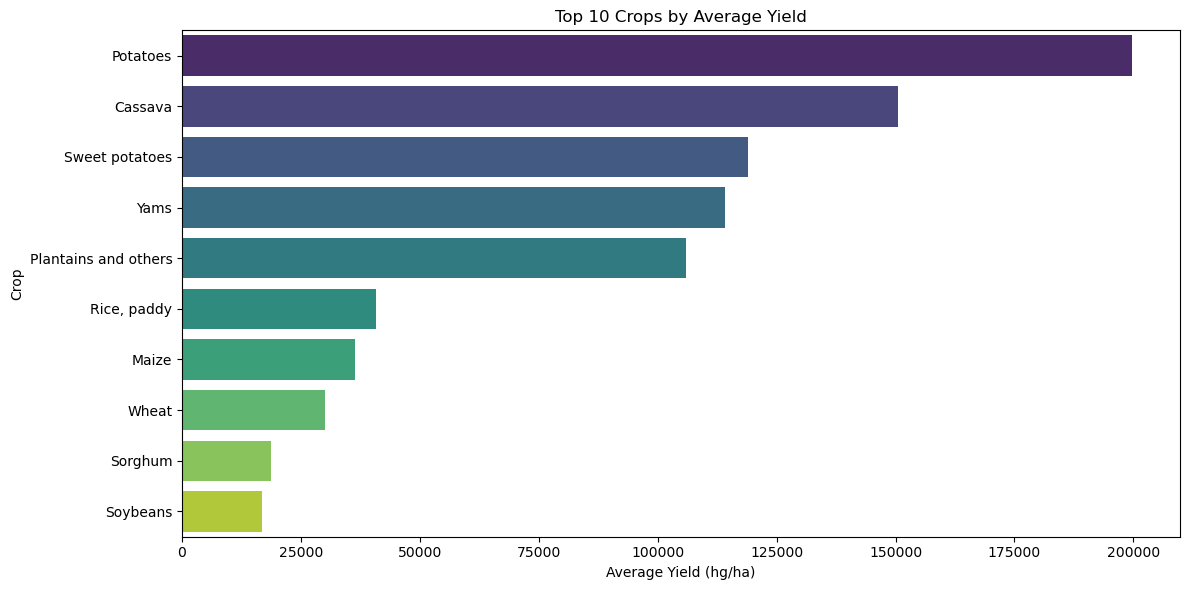

In [7]:
plt.figure(figsize=(12,6))
top_crops = df.groupby('Item')['hg/ha_yield'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_crops.values, y=top_crops.index, palette='viridis')
plt.title('Top 10 Crops by Average Yield')
plt.xlabel('Average Yield (hg/ha)')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()


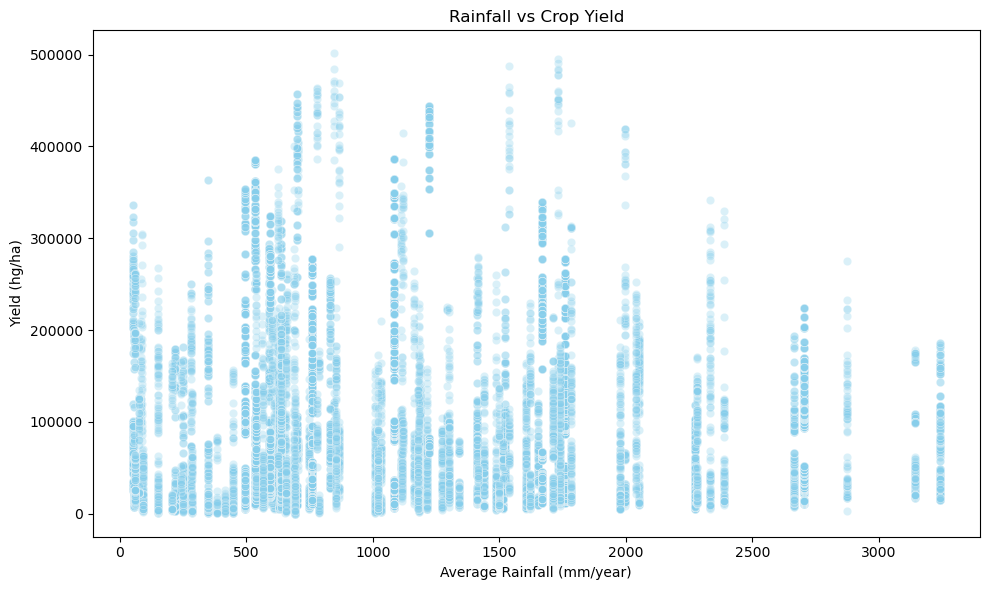

In [8]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='average_rain_fall_mm_per_year', y='hg/ha_yield', data=df, alpha=0.3, color='skyblue')
plt.title('Rainfall vs Crop Yield')
plt.xlabel('Average Rainfall (mm/year)')
plt.ylabel('Yield (hg/ha)')
plt.tight_layout()
plt.show()

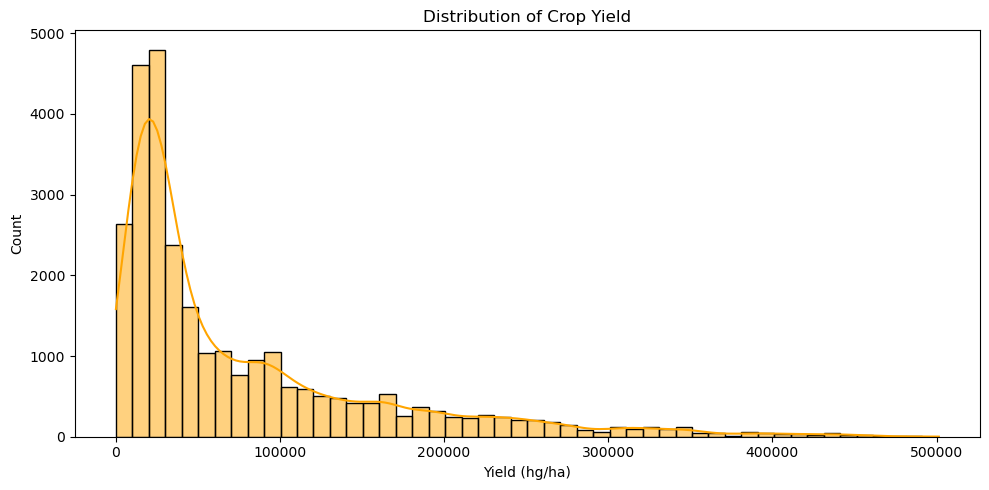

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(df['hg/ha_yield'], bins=50, kde=True, color='orange')
plt.title('Distribution of Crop Yield')
plt.xlabel('Yield (hg/ha)')
plt.tight_layout()
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder

In [11]:
# Drop unnecessary column
df = df.drop('Unnamed: 0', axis=1)

# Encode categorical columns
le = LabelEncoder()
df['Area'] = le.fit_transform(df['Area'])
df['Item'] = le.fit_transform(df['Item'])

print("Data after encoding:")
print(df.head())
print("\nShape:", df.shape)

Data after encoding:
   Area  Item  Year  hg/ha_yield  average_rain_fall_mm_per_year  \
0     0     1  1990        36613                         1485.0   
1     0     3  1990        66667                         1485.0   
2     0     4  1990        23333                         1485.0   
3     0     5  1990        12500                         1485.0   
4     0     6  1990         7000                         1485.0   

   pesticides_tonnes  avg_temp  
0              121.0     16.37  
1              121.0     16.37  
2              121.0     16.37  
3              121.0     16.37  
4              121.0     16.37  

Shape: (28242, 7)


In [12]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop('hg/ha_yield', axis=1)
y = df['hg/ha_yield']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (22593, 6)
X_test shape: (5649, 6)
y_train shape: (22593,)
y_test shape: (5649,)


In [17]:
from xgboost import XGBRegressor

#Create and train model

model = XGBRegressor(n_estimators=100, learning_rate = 0.1, random_state= 42)
model.fit(X_train, y_train)
print("Model trained successfully!")


Model trained successfully!


In [19]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Make Predictions

y_pred = model.predict(X_test)

# Calculate metrics

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R^2 Score: {r2: .4f}")
print(f"RMSE: {rmse: .2f}")
print(f"MAE: {mae: .2f}")


R^2 Score:  0.9606
RMSE:  16895.08
MAE:  9803.33


In [20]:
import pickle

In [22]:
with open('models/yield_model.pkl','wb') as f:
    pickle.dump(model, f)
print("Model is saved successfully!")

Model is saved successfully!
